# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [82]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [83]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users =pd.read_csv ('/datasets/users_latam.csv') #completa el código
usage =pd.read_csv ('/datasets/usage.csv') #completa el código

In [84]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [85]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [86]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [87]:
# revisar el numero de filas y columnas de cada dataset
print("plans","filas y columnas", plans.shape)
print("users", "filas y columnas", users.shape)
print("usage", "filas y columnas", usage.shape)

plans filas y columnas (2, 8)
users filas y columnas (4000, 8)
usage filas y columnas (40000, 6)


In [88]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [89]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [90]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [91]:
# cantidad de nulos para users


nulos = pd.DataFrame({
    'nulos' : users.isna().sum(),
    'porcentaje' : users.isna().mean()*100
}).sort_values('nulos', ascending=False)

print(nulos)




            nulos  porcentaje
churn_date   3534      88.350
city          469      11.725
user_id         0       0.000
first_name      0       0.000
last_name       0       0.000
age             0       0.000
reg_date        0       0.000
plan            0       0.000


In [92]:
nulos = pd.DataFrame({
    'nulos' : usage.isna().sum(),
    'porcentaje' : usage.isna().mean()*100
}).sort_values('nulos', ascending=False)

print(nulos) # cantidad de nulos para usage

          nulos  porcentaje
duration  22076      55.190
length    17896      44.740
date         50       0.125
id            0       0.000
user_id       0       0.000
type          0       0.000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
tabla users:
`churn_date` 3534 Nulos con un porcentaje del 88.35%
`city` 469 Nulos dejando un porcentaje del 11.73%
tabla usage
`duration` 22076 Nulos con un 55.19%
`length` 17869 Nulos cojn el 44.74%
`date` 50 Nulos con menos del 1% (.125%)
- Indica qué harías: ¿imputar, eliminar, ignorar?

- `churn_date` Ignorar El nulo indica que el usuario sigue activo, así que es información útil y no un error.
- `city` Imputar con "Desconocida". Es categórica y eliminar filas perdería casi 12% de los usuarios.
- `duration` Ignorar. Solo aplica a llamadas.
- `length` Ignorar Solo aplica a mensajes; junto con `duration` suma 100%, lo que confirma que son complementarias.
- `date` Eliminar filas Son solo 50 registros <1%, no afecta el análisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [93]:
columnas_numericas = users.select_dtypes(include='number').columns.to_list()

print('Columnas númericas:', columnas_numericas)

users[['user_id', 'age']]  # explorar columnas numéricas de users

Columnas númericas: ['user_id', 'age']


,user_id,age
0,10000,38
1,10001,53
2,10002,57
3,10003,69
4,10004,63
...,...,...
3995,13995,60
3996,13996,24
3997,13997,58
3998,13998,57


- La columna `user_id` Es el numero de identificación del usuario, es un consecutivo que arranca en 10000.
- La columna `age` Es la Edad del usuario.

In [94]:
columnas_numericas = usage.select_dtypes(include='number').columns.to_list()

print('Columnas númericas:', columnas_numericas)

usage[['id', 'user_id', 'duration', 'length']]# explorar columnas numéricas de usage

Columnas númericas: ['id', 'user_id', 'duration', 'length']


,id,user_id,duration,length
0,1,10332,0.09,NaN
1,2,11458,NaN,39.0
2,3,11777,NaN,36.0
3,4,10682,1.53,NaN
4,5,12742,4.84,NaN
...,...,...,...,...
39995,39996,13497,5.75,NaN
39996,39997,10941,3.06,NaN
39997,39998,13038,8.74,NaN
39998,39999,10863,NaN,43.0


- Las columnas `id` y `user_id` Son al igual que el caso anterior indentificadores unicos, uno de usuario y otro de llamada.
- Las columnas `duration` y `length` hacen referencia a la duración de la llamada y al tamaño del mensaje.

In [95]:

columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f'--- {col} ---')
    print(users[col].value_counts(dropna=False))
    print()

--- city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` Nos habla de la ciudad donde se realizo esta acción, recordar que existen algunos valores sin identificación de ciudad.
- La columna `plan` Existen 2 Planes Basic 64% y Premium 36%

In [96]:

# explorar columna categórica de usage
print(usage['type'])

usage['type'].value_counts(dropna=False) # completa el código


0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` Indica si la acción fue una llamada o un mensaje.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [97]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [98]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [99]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, En `reg_date`, los años 2022, 2023 y 2024 tienen cantidades similares (~1,300 usuarios cada uno), lo que es consistente. Sin em
bargo, aparecen 40 registros en 2026, lo cual es imposible porque los datos llegan solo hasta 2024. Son fechas mal capturadas y deben tratarse (convertir a nulo o eliminar) antes del análisis.

In [100]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, En `date`, todos los registros válidos (39,950) corresponden a 2024, así que no hay fechas fuera de rango. Los 50 registros restantes son los nulos detectados antes (39,950 + 50 = 40,000). El año aparece como `2024.0` (decimal) porque la columna contiene nulos
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**¿Aparecen años imposibles?**

- `reg_date` (users): Sí. Hay 40 registros con año 2026, que no había transcurrido al momento de guardar los datos (llegan hasta 2024). No aparecen años demasiado antiguos; el más viejo es 2022, que es razonable.
- `date` (usage): No. Los 39,950 registros con fecha corresponden a 2024, todos dentro del rango válido. Los 50 restantes son nulos, no fechas erróneas.

**¿Qué harías con ellas?**
- `reg_date` 2026  Convertir a nulo (NaT), no eliminar las filas. Solo la fecha está mal; el resto de la información del usuario sigue siendo útil para el análisis.
- `date` Sin acción por fechas fuera de rango. Los 50 nulos ya se trataron en la sección de valores nulos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [101]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [102]:
# Reemplazar ? por NA en city
print(users['city'].value_counts(dropna=False))


# Verificar cambios
print('Nulos en city:', users['city'].isna().sum())

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Nulos en city: 469


In [103]:
# Marcar fechas futuras como NA para reg_date

users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024)

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())
print('Nulos en reg_date:', users['reg_date'].isna().sum())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64
Nulos en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [104]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean() * 100

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [105]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean() * 100

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

- `duration`: los nulos se concentran casi al 100% en los registros de tipo mensaje, y prácticamente no hay nulos en las llamadas. Esto confirma que son MAR, porque su ausencia depende de `type`: un mensaje no tiene duración.
- `length`: ocurre lo contrario; los nulos están casi al 100% en las llamadas, porque una llamada no tiene longitud en caracteres. También son MAR.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [106]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [107]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [108]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [109]:
# Resumen estadístico de las columnas numéricas


In [110]:
# Distribución porcentual del tipo de plan


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

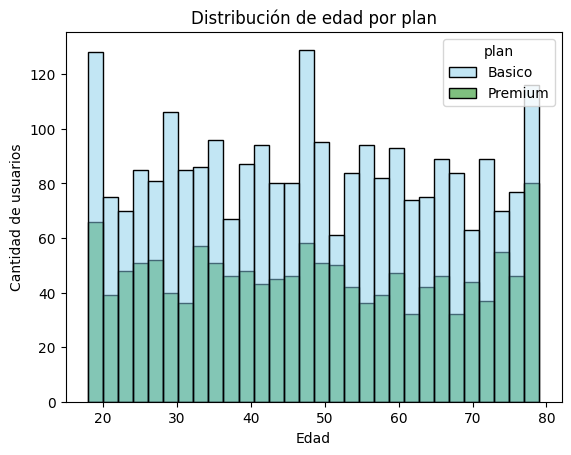

array([38., 53., 57., 69., 63., 61., 39., 70., 76., 47., 67., 60., 48.,
       78., 77., 25., 51., 74., 64., 26., 68., 37., 42., 36., 22., 28.,
       32., 40., 44., 49., 43., 79., 59., 46., 56., 58., 50., 54., 33.,
       24., 29., 45., 66., 30., 35., 65., 18., 55., 19., 23., 41., 27.,
       34., 72., 75., 31., 71., 52., 20., 73., 21., 62.])

In [111]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=30)
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

users['age'].unique()

💡Insights: 

- **Distribución:** aproximadamente uniforme entre los 18 y 80 años; no hay una edad dominante. Destacan algunos picos en los extremos (18 y 79 años) y cerca de los 47.
- **Por plan:** no existe un patrón claro; ambos planes tienen usuarios en todas las edades con la misma forma. El plan Básico tiene más usuarios en todos los rangos, pero en proporción similar.

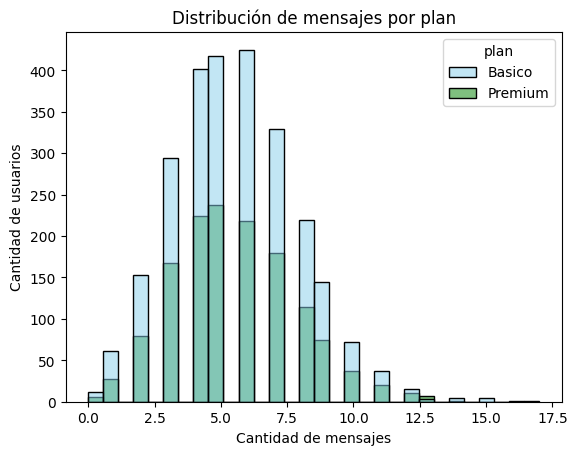

In [112]:

# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=30)
plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()




💡Insights: 
- **Distribución:** ligeramente sesgada a la derecha. La mayoría de los usuarios envía entre 3 y 7 mensajes, y muy pocos superan los 12.
- **Por plan:** no existe un patrón claro; Básico y Premium tienen la misma forma y se concentran en el mismo rango. El tipo de plan no parece influir en la cantidad de mensajes.

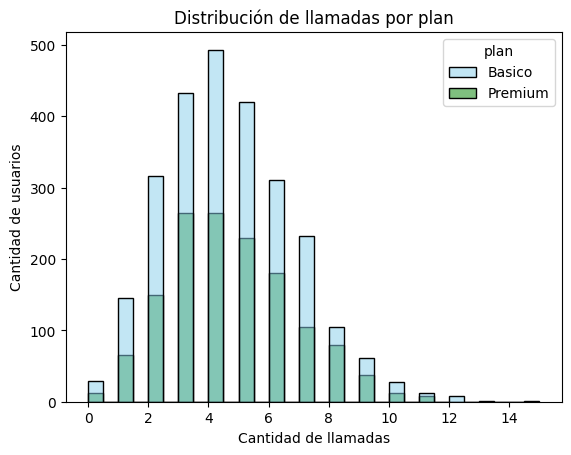

In [113]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=30)
plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()



💡Insights: 
- **Distribución:** ligeramente sesgada a la derecha. La mayoría de los usuarios hace entre 2 y 6 llamadas, con un pico alrededor de 4, y pocos pasan de 10.
- **Por plan:** no existe un patrón claro; ambos planes se concentran en el mismo rango. Los usuarios Premium no hacen notablemente más llamadas que los Básico.

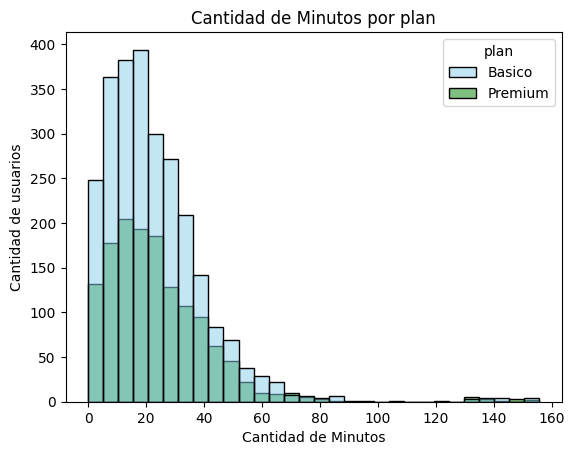

In [114]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=30)
plt.title('Cantidad de Minutos por plan')
plt.xlabel('Cantidad de Minutos')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- **Distribución:** claramente sesgada a la derecha. La mayoría de los usuarios acumula entre 5 y 30 minutos, y la frecuencia cae conforme aumentan los minutos.
- **Por plan:** la forma es similar en ambos planes en el rango principal.
- **Outliers:** aparece un pequeño grupo separado entre 130 y 155 minutos, muy alejado del resto. Son posibles valores atípicos que conviene revisar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

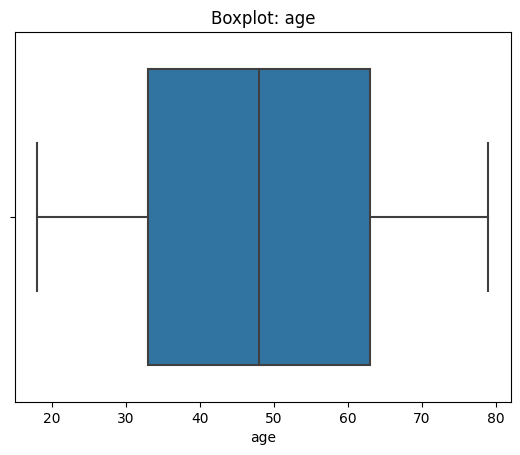

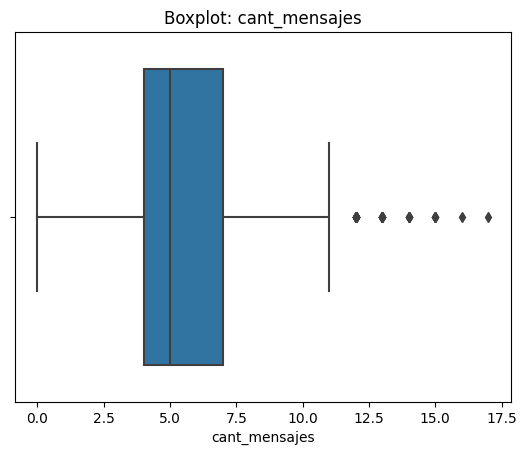

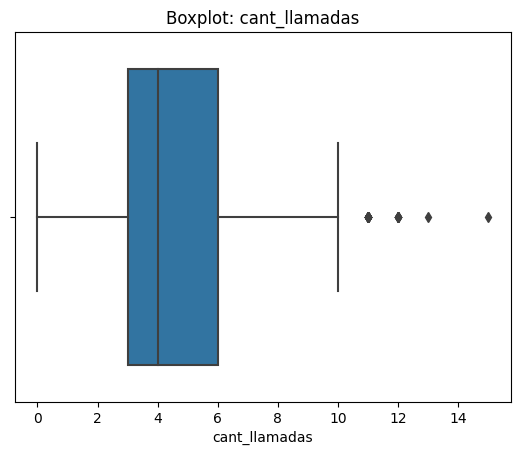

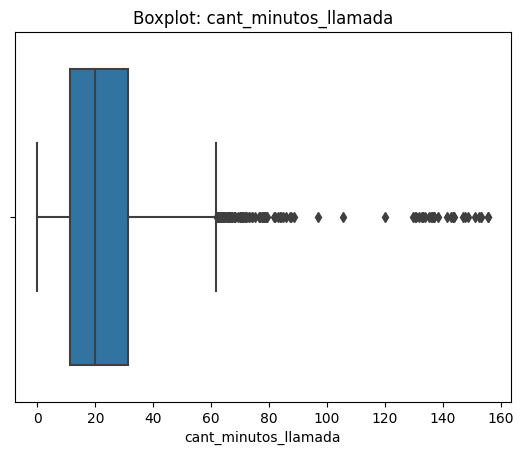

In [115]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- **age:** no presenta outliers. Las edades van de 18 a 79 años, con la mediana cerca de los 48 y el 50% central entre 33 y 63 años. La distribución es amplia pero sin valores extremos.
- **cant_mensajes:** presenta outliers solo del lado derecho. La mayoría envía entre 4 y 7 mensajes (mediana 5) y los outliers van de 12 a 17 mensajes. Son pocos usuarios y los valores son razonables.
- **cant_llamadas:** presenta outliers solo del lado derecho. La mayoría hace entre 3 y 6 llamadas (mediana 4) y los outliers están entre 11 y 15 llamadas. También son pocos y valores posibles.
- **cant_minutos_llamada:** es la variable con más outliers, todos del lado derecho. Además de una cola continua de valores altos, aparece un grupo separado en el extremo (130–155 minutos) que se aleja claramente del resto.

In [116]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f'{col}: límite superior = {limite_superior:.2f}')


cant_mensajes: límite superior = 11.50
cant_llamadas: límite superior = 10.50
cant_minutos_llamada: límite superior = 61.86


In [117]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes: mantener outliers.** El límite superior es 11.5 y el máximo es 17, una diferencia moderada. Enviar entre 12 y 17 mensajes es un comportamiento realista de usuarios más activos, no un error.
- **cant_llamadas: mantener outliers.** El límite superior es 10.5 y el máximo es 15. Son valores cercanos al límite y perfectamente posibles; representan clientes de uso intensivo que aportan información importante
- **cant_minutos_llamada: mantener outliers, pero marcar el grupo extremo para revisión.** El límite superior es 61.86 y el máximo es 155.69, más del doble del límite. Además, la media (23.3) es mayor que la mediana (19.8), lo que confirma el sesgo a la derecha causado por estos valores. El grupo de 130–155 minutos está separado del resto de la distribución, por lo que podría ser un segmento distinto o un error de registro; no se elimina sin verificarlo, pero conviene considerar su efecto en promedios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [118]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'

user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

In [119]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [120]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[user_profile['age'] < 60, 'grupo_edad'] = 'Adulto'

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

In [121]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

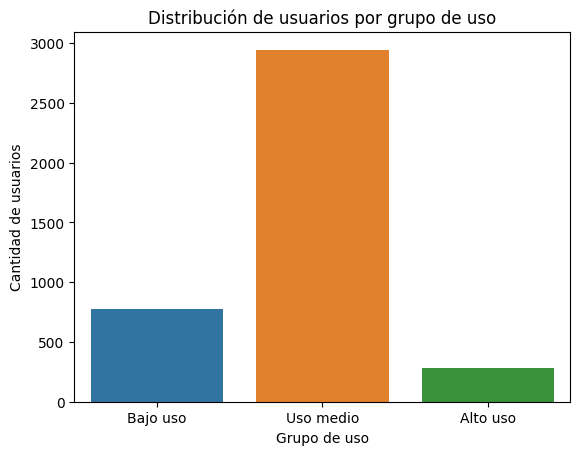

In [122]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

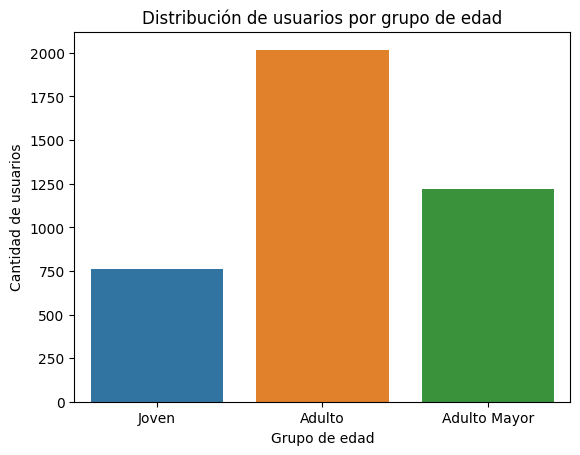

In [123]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En `users`, la edad tenía registros con el valor -999, que no es una edad real; se reemplazaron con la mediana (48 años) para no perder esos clientes.
  
- La ciudad venía incompleta: 469 usuarios sin ciudad (11.7%) y otros 96 marcados con "?", así que cerca del 14% de la base no tiene ubicación confiable.

  
- Había 40 usuarios (1%) con fecha de registro en 2026, algo imposible porque los datos llegan hasta 2024. Se marcaron como nulos sin borrar al cliente.

  
- En `usage`, 50 registros (0.1%) no tenían fecha. Los nulos en `duration` (55%) y `length` (45%) no son un error: cada registro es llamada o mensaje, nunca ambos.

  
- `churn_date` está vacía en el 88% de los casos porque esos clientes siguen activos, los 466 con fecha (11.6%) son los que se fueron.


🔍 **Segmentos por Edad**
- La base se concentra en adultos de 30 a 59 años (2,000 usuarios, la mitad del total), seguidos por adultos mayores (1,200, 30%) y jóvenes (760, 19%).
- 
- La edad no cambia la forma de usar el servicio: jóvenes, adultos y mayores mandan mensajes y hacen llamadas en cantidades muy parecidas, y la proporción entre planes Básico y Premium se mantiene igual en todas las edades.


📊 **Segmentos por Nivel de Uso**
- Tres de cada cuatro clientes (2,940, 73%) están en uso medio. Solo 780 (19%) son de bajo uso y~280 (7%) de alto uso.

- El consumo es muy bajo en general: a lo largo de 2024 un usuario típico hizo 4 llamadas, envió 5 mensajes y habló unos 20 minutos en total.

  
- Los clientes Premium no usan más que los Básico. Ambos planes tienen prácticamente el mismo comportamiento en llamadas, mensajes y minutos.

  
- Hay clientes con uso extremo que vale la pena mirar: algunos llegan a 17 mensajes o 15 llamadas, y un grupo pequeño acumula entre 130 y 155 minutos, más del doble del límite normal (62). No parecen errores sino clientes intensivos.


➡️ Esto sugiere que los planes actuales están sobredimensionados para lo que la gente realmente usa. El plan Básico ya incluye 100 minutos y 100 mensajes al mes, y la mayoría de los clientes no llega a eso ni en un año. Los clientes Premium pagan más del doble ($25 contra $12) por una capacidad que no aprovechan, lo que los pone en riesgo de bajarse de plan o cancelar si es que llegarán a notarlo.


💡 **Recomendaciones**
- Revisar el valor del plan Premium: si no se distingue por minutos ni mensajes, conviene diferenciarlo con algo que sí se use, como más datos móviles, beneficios o atención preferente.
- Crear un plan de entrada más barato para el 19% de bajo uso, que hoy paga por minutos y mensajes que no consume y puede irse por precio.
- Cuidar al 7% de alto uso: son los clientes más comprometidos con el servicio y los más valiosos para retener, así que tiene sentido ofrecerles promociones de lealtad antes de que busquen otra opción.
- Analizar a los 466 clientes que se dieron de baja por segmento de uso y plan para saber quiénes se están yendo y por qué.
- Mejorar la captura de datos, sobre todo la ciudad, porque sin ubicación no se pueden hacer campañas por región.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`